# Comparing Background Dataset Strategies in ShaTS

This notebook compares different strategies for building the `background_dataset` used by ShaTS.

The pipeline is based on the example_toy_dataset example notebook and keeps the same steps:

- build and preprocess the synthetic dataset
- train or load the anomaly detection model
- wrap the model to return class probabilities
- generate different background datasets from the training windows
- compare ShaTS explanations obtained with each background strategy

The strategies covered are:

- **RANDOM**
- **ENTROPY**
- **STRATIFIED**
- **KMEANS**

The comparison focuses on the **feature grouping strategy** so that the impact of the background selection is easier to interpret across variables.


## 1. AD Framework Configuration

#### Imports and config

In [3]:
import pandas as pd
import numpy as np
import random

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### 1.1 Data preprocessing

#### Dataset creation

This synthetic dataset simulates data for anomaly detection (AD) with 10,000 samples and 50 features. It includes 5 categorical variables with random integer values and 45 continuous features with smoothed temporal fluctuations. Continuous data is smoothed using a moving average to reflect temporal dependencies. Labels (normal = 0, attack = 1) are generated using a non-linear rule based on the even-odd combination of **just continuous features** (categorical features has no influence).

In [5]:
# Parámetros del dataset sintético
n_samples = 10000
n_features = 50
categorical_columns = [f'Cat{i}' for i in range(5)]
continuous_columns = [f'Cont{i}' for i in range(n_features - len(categorical_columns))]

# Generación de datos sintéticos
np.random.seed(42)
categorical_data = np.random.randint(0, 5, size=(n_samples, len(categorical_columns)))

# Generar datos aleatorios centrados en 0 para fluctuación
dataCont = np.random.randn(n_samples, len(continuous_columns))

# Crear un array para almacenar los resultados con fluctuación controlada
continuous_data = np.zeros_like(dataCont)

for i in range(n_samples):
    # Calcular el rango de la ventana móvil
    start = max(0, i - 10 + 1)
    # Calcular la media acumulada dentro de la ventana
    window_mean = np.mean(dataCont[start:i+1], axis=0)
    # Añadir el valor medio en lugar de la suma acumulada
    continuous_data[i] = window_mean

# Generación de etiquetas basadas en una función no lineal de las características
labels = pd.Series(np.zeros(n_samples))
for i in range(n_samples):
    #suma las continuous data pares y resta los impares
    linear_combination = 0
    for j in range(len(continuous_columns)):
        if j % 2 == 0:
            linear_combination += continuous_data[i, j]
        else:
            linear_combination -= continuous_data[i, j]
    
    if linear_combination > 0:
        labels[i] = 1

# Crear DataFrame sintético
data = pd.DataFrame(np.hstack([categorical_data, continuous_data]), columns=categorical_columns + continuous_columns)
data['Normal/Attack'] = labels
data['Index'] = data.index
data = data.drop(columns=['Normal/Attack'])

print(data.head())

   Cat0  Cat1  Cat2  Cat3  Cat4     Cont0     Cont1     Cont2     Cont3  \
0   3.0   4.0   2.0   4.0   4.0  1.752429 -0.291520 -0.350569 -1.869980   
1   1.0   2.0   2.0   2.0   4.0  1.076240  0.201538 -0.724296 -1.043338   
2   3.0   2.0   4.0   1.0   3.0  0.764186  0.087515 -0.490137 -0.653486   
3   1.0   3.0   4.0   0.0   3.0  0.065802  0.396573 -0.230036 -0.645557   
4   1.0   4.0   3.0   0.0   0.0  0.140822  0.349283 -0.561272 -0.435195   

      Cont4  ...    Cont36    Cont37    Cont38    Cont39    Cont40    Cont41  \
0  0.690073  ...  0.687049 -0.753650  0.507943  0.113100 -0.057752 -1.241423   
1  0.602920  ... -0.086847 -0.905164  0.185658  0.124826  0.707720 -0.559046   
2  0.562293  ... -0.506509 -0.410285  0.422424 -0.233332  0.393032 -0.310591   
3  0.637821  ... -0.476443 -0.136543  0.048090  0.212492  0.529242 -0.067564   
4  0.628435  ... -0.502941 -0.171857  0.340737  0.192653  0.409208 -0.052523   

     Cont42    Cont43    Cont44  Index  
0  0.153253  0.184957  0.10

In [6]:
# porcentaje de anomalías y trafico normal
anomaly_percentage = labels.value_counts(normalize=True)[1]
normal_percentage = labels.value_counts(normalize=True)[0]
print(f"Anomaly percentage: {anomaly_percentage:.2%}")
print(f"Normal percentage: {normal_percentage:.2%}")

Anomaly percentage: 49.69%
Normal percentage: 50.31%


#### Data preprocessing: Windowing

In [7]:
segment_size = 500
padding_size = 50
train_percentage = 0.7
val_percentage = 0.15
test_percentage = 0.15

In [8]:
train_data_list, val_data_list, test_data_list, padding_data_list = [], [], [], []
train_labels_list, val_labels_list, test_labels_list, padding_labels_list = [], [], [], []
train_indexes_list, val_indexes_list, test_indexes_list, padding_indexes_list = [], [], [], []

for i in range(0, len(data), segment_size):

    init = i
    end = min(i + segment_size, len(data))

    segment_indexes = data['Index'].iloc[init:end]
    
    segment_data = data.iloc[init:end]
    segment_labels = labels.iloc[init:end]
    
    train_split_index = int(train_percentage * len(segment_data))
    val_split_index = int((train_percentage + val_percentage) * len(segment_data))
    
    #TRAIN
    train_data_list.append(segment_data.iloc[:train_split_index])
    train_labels_list.append(segment_labels.iloc[:train_split_index])
    
    # Padding before VALIDATION
    padding_start = max(0, train_split_index - padding_size)
    padding_data_list.append(segment_data.iloc[padding_start:train_split_index])
    padding_labels_list.append(segment_labels.iloc[padding_start:train_split_index])
    
    # VALIDATION
    val_data_list.append(segment_data.iloc[train_split_index:val_split_index])
    val_labels_list.append(segment_labels.iloc[train_split_index:val_split_index])
    
    # Padding before TEST
    padding_start_val = max(0, val_split_index - padding_size)
    padding_end_val = min(len(segment_data), val_split_index + padding_size)
    padding_data_list.append(segment_data.iloc[padding_start_val:val_split_index])
    padding_labels_list.append(segment_labels.iloc[padding_start_val:val_split_index])
    
    # TEST
    test_data_list.append(segment_data.iloc[val_split_index:])
    test_labels_list.append(segment_labels.iloc[val_split_index:])
    
    # Padding before next SEGMENT
    padding_end = min(len(segment_data), val_split_index + padding_size)
    padding_data_list.append(segment_data.iloc[val_split_index:padding_end])
    padding_labels_list.append(segment_labels.iloc[val_split_index:padding_end])

    train_indexes_list.append(segment_indexes.iloc[:train_split_index])
    val_indexes_list.append(segment_indexes.iloc[train_split_index:val_split_index])
    test_indexes_list.append(segment_indexes.iloc[val_split_index:])


# Concatenate
train_data = pd.concat(train_data_list).reset_index(drop=True)
val_data = pd.concat(val_data_list).reset_index(drop=True)
test_data = pd.concat(test_data_list).reset_index(drop=True)
padding_data = pd.concat(padding_data_list).reset_index(drop=True)

train_labels = pd.concat(train_labels_list).reset_index(drop=True)
val_labels = pd.concat(val_labels_list).reset_index(drop=True)
test_labels = pd.concat(test_labels_list).reset_index(drop=True)
padding_labels = pd.concat(padding_labels_list).reset_index(drop=True)

train_indexes = pd.concat(train_indexes_list).reset_index(drop=True)
val_indexes = pd.concat(val_indexes_list).reset_index(drop=True)
test_indexes = pd.concat(test_indexes_list).reset_index(drop=True)


print(f'Train data shape: {train_data.shape}')
print(f'Train labels shape: {train_labels.shape}')
print(f'Train index shape: {train_indexes.shape}')
print()

print(f'Validation data shape: {val_data.shape}')
print(f'Validation labels shape: {val_labels.shape}')
print(f'Validation index shape: {val_indexes.shape}')
print()

print(f'Test data shape: {test_data.shape}')
print(f'Test labels shape: {test_labels.shape}')
print(f'Test index shape: {test_indexes.shape}')
print()

x_train = train_data.to_numpy()
y_train = train_labels.to_numpy()
x_val = val_data.to_numpy()
y_val = val_labels.to_numpy()
x_test = test_data.to_numpy()
y_test = test_labels.to_numpy()

Train data shape: (7000, 51)
Train labels shape: (7000,)
Train index shape: (7000,)

Validation data shape: (1500, 51)
Validation labels shape: (1500,)
Validation index shape: (1500,)

Test data shape: (1500, 51)
Test labels shape: (1500,)
Test index shape: (1500,)



In [9]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, labels, indexes, stride=1, window_size=10):

        self.x = data.to_numpy(dtype=np.float32)  
        self.labels = labels.to_numpy(dtype=np.float32)  
        self.labels = np.array([[1, 0] if label == 0 else [0, 1] for label in self.labels], dtype=np.float32)
        self.indexes = indexes.to_numpy(dtype=np.int32)  
        self.window_size = window_size
        self.stride = stride

        self.valid_idxs = self._preprocess_windows()
        self.n_idxs = len(self.valid_idxs)

    def __len__(self):
        return self.n_idxs

    def __getitem__(self, idx):
        i = self.valid_idxs[idx]
        item = {}
        item["given"] = torch.from_numpy(self.x[i:i + self.window_size]).to(torch.float32)
        item["label"] = torch.tensor(self.labels[i + self.window_size - 1], dtype=torch.float32).to(device)
        item["answer"] = torch.tensor(self.labels[i + self.window_size-1], dtype=torch.float32).to(device)
        item["indexes"] = self.indexes[i + self.window_size - 1]
        return item

    def _preprocess_windows(self):
        temp_valid_idxs = []
        total_windows = len(self.x) - self.window_size + 1
        print(f"Total windows: {total_windows}")
        
        for L in range(0, total_windows, self.stride):
            window_indices = self.indexes[L:L + self.window_size]
            
            if np.all(np.diff(window_indices) == 1):
                temp_valid_idxs.append(L)
        
        print(f"Valid windows: {len(temp_valid_idxs)}")
        return np.array(temp_valid_idxs, dtype=np.int32)

#### Data preprocessing: Removing 0-variance features, identifying continuous and categorical features

In [10]:
zero_variance_columns = train_data.columns[train_data.nunique() <= 1].tolist()

train_data_trans = train_data.drop(columns=['Index'])
val_data_trans = val_data.drop(columns=['Index'])
test_data_trans = test_data.drop(columns=['Index'])

train_data_trans = train_data_trans.drop(columns=zero_variance_columns)
val_data_trans = val_data_trans.drop(columns=zero_variance_columns)
test_data_trans = test_data_trans.drop(columns=zero_variance_columns)

categorical_columns = [col for col in train_data_trans.columns if train_data_trans[col].nunique() < 10]
continuous_columns = [col for col in train_data_trans.columns if col not in categorical_columns]

print(f"Zero variance columns: {len(zero_variance_columns)}: {zero_variance_columns}")
print(f'Categorical columns: {len(categorical_columns)}: {categorical_columns}')
print(f'Continuous columns: {len(continuous_columns)}: {continuous_columns}')

Zero variance columns: 0: []
Categorical columns: 5: ['Cat0', 'Cat1', 'Cat2', 'Cat3', 'Cat4']
Continuous columns: 45: ['Cont0', 'Cont1', 'Cont2', 'Cont3', 'Cont4', 'Cont5', 'Cont6', 'Cont7', 'Cont8', 'Cont9', 'Cont10', 'Cont11', 'Cont12', 'Cont13', 'Cont14', 'Cont15', 'Cont16', 'Cont17', 'Cont18', 'Cont19', 'Cont20', 'Cont21', 'Cont22', 'Cont23', 'Cont24', 'Cont25', 'Cont26', 'Cont27', 'Cont28', 'Cont29', 'Cont30', 'Cont31', 'Cont32', 'Cont33', 'Cont34', 'Cont35', 'Cont36', 'Cont37', 'Cont38', 'Cont39', 'Cont40', 'Cont41', 'Cont42', 'Cont43', 'Cont44']


In [11]:
for col in categorical_columns:
    train_data_trans[col] = train_data_trans[col].astype('category')
    val_data_trans[col] = val_data_trans[col].astype('category')
    test_data_trans[col] = test_data_trans[col].astype('category')

In [12]:
#Standardize continuous columns and one-hot encode categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), continuous_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_columns)
    ]
)

pipeline = Pipeline(steps=[("preprocessor", preprocessor)])

pipeline.fit(train_data_trans)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Cont0', 'Cont1', 'Cont2',
                                                   'Cont3', 'Cont4', 'Cont5',
                                                   'Cont6', 'Cont7', 'Cont8',
                                                   'Cont9', 'Cont10', 'Cont11',
                                                   'Cont12', 'Cont13', 'Cont14',
                                                   'Cont15', 'Cont16', 'Cont17',
                                                   'Cont18', 'Cont19', 'Cont20',
                                                   'Cont21', 'Cont22', 'Cont23',
                                                   'Cont24', 'Cont25', 'Cont26',
                                                   'Cont27', 'Cont28', 'Cont29', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Cat0', 'Cat1', 'Cat2',
                                                   'Cat3', 'Cat4'])]))])

In [13]:
x_train_trans = pipeline.transform(train_data_trans)
x_val_trans = pipeline.transform(val_data_trans)
x_test_trans = pipeline.transform(test_data_trans)

In [14]:
categorical_feature_names = pipeline.named_steps["preprocessor"].transformers_[1][1].get_feature_names_out(categorical_columns)
all_feature_names = continuous_columns + list(categorical_feature_names)

x_train_df = pd.DataFrame(x_train_trans, columns=all_feature_names)
x_val_df = pd.DataFrame(x_val_trans, columns=all_feature_names)
x_test_df = pd.DataFrame(x_test_trans, columns=all_feature_names)

x_train_df.head()

,Cont0,Cont1,Cont2,Cont3,Cont4,Cont5,Cont6,Cont7,Cont8,Cont9,...,Cat3_0.0,Cat3_1.0,Cat3_2.0,Cat3_3.0,Cat3_4.0,Cat4_0.0,Cat4_1.0,Cat4_2.0,Cat4_3.0,Cat4_4.0
0,5.433623,-0.886929,-1.134649,-5.940902,2.222566,-2.155915,0.470116,-1.038447,-1.509999,-0.392417,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,3.347292,0.660716,-2.332001,-3.310100,1.944515,-1.471800,1.774260,-0.392639,-4.014728,1.125772,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2.384473,0.302814,-1.581799,-2.069389,1.814896,0.241395,-1.243241,0.910149,-4.579530,1.070694,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.229663,1.272906,-0.748483,-2.044156,2.055861,-0.619802,-0.840824,0.864100,-3.246244,0.132328,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.461131,1.124468,-1.809701,-1.374675,2.025916,-1.636106,-1.435433,2.000459,-2.726757,0.721066,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [15]:
print(f"Train data transformed shape: {x_train_df.shape}")
print(f"Validation data transformed shape: {x_val_df.shape}")
print(f"Test data transformed shape: {x_test_df.shape}")
variable_names = all_feature_names
print("Variables names after transformation:")
print(variable_names)

Train data transformed shape: (7000, 70)
Validation data transformed shape: (1500, 70)
Test data transformed shape: (1500, 70)
Variables names after transformation:
['Cont0', 'Cont1', 'Cont2', 'Cont3', 'Cont4', 'Cont5', 'Cont6', 'Cont7', 'Cont8', 'Cont9', 'Cont10', 'Cont11', 'Cont12', 'Cont13', 'Cont14', 'Cont15', 'Cont16', 'Cont17', 'Cont18', 'Cont19', 'Cont20', 'Cont21', 'Cont22', 'Cont23', 'Cont24', 'Cont25', 'Cont26', 'Cont27', 'Cont28', 'Cont29', 'Cont30', 'Cont31', 'Cont32', 'Cont33', 'Cont34', 'Cont35', 'Cont36', 'Cont37', 'Cont38', 'Cont39', 'Cont40', 'Cont41', 'Cont42', 'Cont43', 'Cont44', 'Cat0_0.0', 'Cat0_1.0', 'Cat0_2.0', 'Cat0_3.0', 'Cat0_4.0', 'Cat1_0.0', 'Cat1_1.0', 'Cat1_2.0', 'Cat1_3.0', 'Cat1_4.0', 'Cat2_0.0', 'Cat2_1.0', 'Cat2_2.0', 'Cat2_3.0', 'Cat2_4.0', 'Cat3_0.0', 'Cat3_1.0', 'Cat3_2.0', 'Cat3_3.0', 'Cat3_4.0', 'Cat4_0.0', 'Cat4_1.0', 'Cat4_2.0', 'Cat4_3.0', 'Cat4_4.0']


In [16]:
trainDataset = TimeSeriesDataset(data=pd.DataFrame(x_train_df) , labels=train_labels, indexes=train_indexes , stride=1, window_size=10)
valDataset = TimeSeriesDataset(data=pd.DataFrame(x_val_df) , labels=val_labels, indexes=val_indexes , stride=1, window_size=10)
testDataset = TimeSeriesDataset(data=pd.DataFrame(x_test_df) , labels=test_labels, indexes=test_indexes , stride=1, window_size=10)

Total windows: 6991
Valid windows: 6820
Total windows: 1491
Valid windows: 1320
Total windows: 1491
Valid windows: 1320


In [17]:
#For each original variable, store the indices of the generated variables in all_feature_names

variables_map = {}

#Continuous variables
for v in continuous_columns:
    variables_map[v] = [all_feature_names.index(v)]  

#Categorical variables
encoder = pipeline.named_steps["preprocessor"].transformers_[1][1] 
for v, categories in zip(categorical_columns, encoder.categories_):
    encoded_names = [f"{v}_{category}" for category in categories]
    indexes = [all_feature_names.index(name) for name in encoded_names]
    variables_map[v] = indexes

### 1.2 AD Model Training and Evaluation

#### AD Model definition

In [18]:
class StackedLSTM(torch.nn.Module):

    def __init__(self, n_tags, n_classes, hidden_size=64, num_layers=3, bidirectional=True, dropout=0):
        super().__init__()
        self.rnn = torch.nn.LSTM(
            input_size=n_tags,
            hidden_size=hidden_size,
            num_layers=num_layers,
            bidirectional=bidirectional,
            dropout=dropout,
        )
        self.fc = torch.nn.Linear(2*hidden_size if bidirectional else hidden_size, n_classes)

    def forward(self, x):
        x = x.transpose(0, 1)
        self.rnn.flatten_parameters()
        outs, _ = self.rnn(x)
        out = self.fc(outs[-1])
        return out

#### Training/Loading the AD model

In [24]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce_loss = nn.CrossEntropyLoss()

    def forward(self, inputs, targets):
        ce_loss = self.ce_loss(inputs, targets)
        pt = torch.exp(-ce_loss)  
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

# Optimal hyperparameters
input_dim = trainDataset[0]['given'].shape[1]
hidden_dim = 32
num_layers = 2
dropout = 0.2
num_classes = 2
learning_rate = 0.001
num_epochs = 20
batch_size = 2048
alpha = 1
gamma = 2


model = StackedLSTM(n_tags=input_dim, n_classes=num_classes, hidden_size=hidden_dim, num_layers=num_layers).to(device)
criterion = FocalLoss(alpha=alpha, gamma=gamma)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


train_loader = DataLoader(trainDataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(valDataset, batch_size=batch_size, shuffle=False)

trainBool = True
if trainBool:

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for data_batch in train_loader:
            x_batch = data_batch["given"].to(device)
            y_batch = data_batch["label"].to(device)

            optimizer.zero_grad()
            outputs = model(x_batch)
            y_batch_indices = torch.argmax(y_batch, dim=1)            
            loss = criterion(outputs, y_batch_indices)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f'Epoch [{epoch+1}/{num_epochs}], Training Loss: {avg_loss:.4f}')

        model.eval()
        val_loss = 0
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for data_batch in val_loader:
                x_batch = data_batch["given"].to(device)
                y_batch = data_batch["label"].to(device)
                outputs = model(x_batch)
                y_batch_indices = torch.argmax(y_batch, dim=1)
                predicted = torch.argmax(outputs, dim=1)
                loss = criterion(outputs, y_batch_indices)
                val_loss += loss.item()
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(y_batch_indices.cpu().numpy())

        val_loss /= len(val_loader)

        all_preds = np.array(all_preds).reshape(-1)
        all_labels = np.array(all_labels).reshape(-1)

        accuracy = (all_preds == all_labels).mean()
        precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
        recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
        f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

        print(f'Validation Loss: {val_loss:.4f} | Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1-score: {f1:.4f}\n')

    torch.save(model.state_dict(), 'SinteticModel.pt')

else:
    model.load_state_dict(torch.load('SinteticModel.pt'))

Epoch [1/20], Training Loss: 0.1704
Validation Loss: 0.1669 | Accuracy: 0.6515 | Precision: 0.6829 | Recall: 0.6568 | F1-score: 0.6404

Epoch [2/20], Training Loss: 0.1640
Validation Loss: 0.1603 | Accuracy: 0.6606 | Precision: 0.7282 | Recall: 0.6678 | F1-score: 0.6391

Epoch [3/20], Training Loss: 0.1556
Validation Loss: 0.1508 | Accuracy: 0.6803 | Precision: 0.7495 | Recall: 0.6873 | F1-score: 0.6614

Epoch [4/20], Training Loss: 0.1438
Validation Loss: 0.1370 | Accuracy: 0.7242 | Precision: 0.7787 | Recall: 0.7301 | F1-score: 0.7133

Epoch [5/20], Training Loss: 0.1282
Validation Loss: 0.1181 | Accuracy: 0.7523 | Precision: 0.7922 | Recall: 0.7572 | F1-score: 0.7458

Epoch [6/20], Training Loss: 0.1079
Validation Loss: 0.0958 | Accuracy: 0.7848 | Precision: 0.8051 | Recall: 0.7883 | F1-score: 0.7825

Epoch [7/20], Training Loss: 0.0852
Validation Loss: 0.0748 | Accuracy: 0.7992 | Precision: 0.8047 | Recall: 0.8010 | F1-score: 0.7989

Epoch [8/20], Training Loss: 0.0665
Validation L

#### Model evaluation

Test Accuracy: 0.9212 | Precision: 0.9213 | Recall: 0.9211 | F1-score: 0.9212



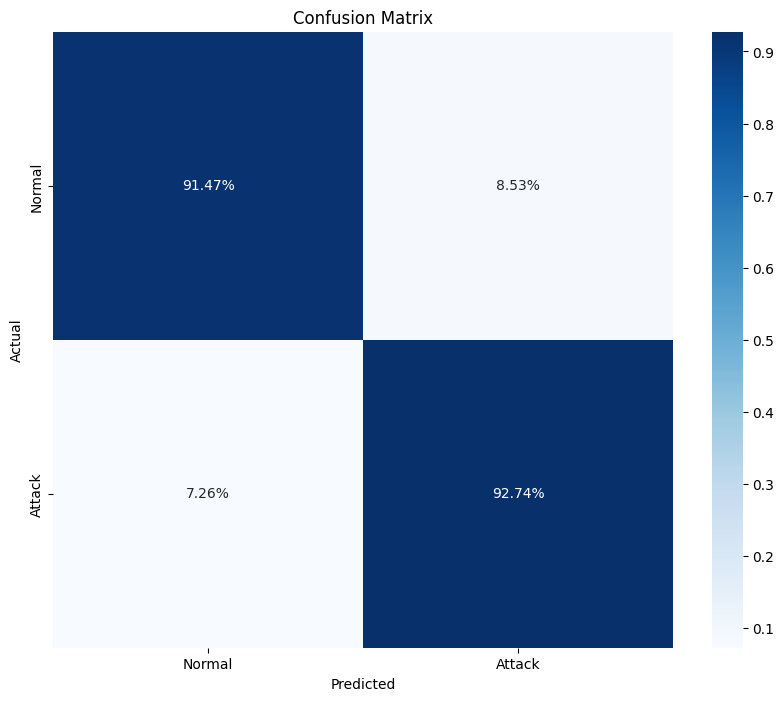

In [25]:
model.eval()
test_loader = DataLoader(testDataset, batch_size=batch_size, shuffle=False)

all_preds = []
all_labels = []

with torch.no_grad():
    for data_batch in test_loader:
        x_batch = data_batch["given"].to(device)
        y_batch = data_batch["label"].to(device)
        outputs = model(x_batch)
        y_batch_indices = torch.argmax(y_batch, dim=1)
        predicted = torch.argmax(outputs, dim=1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch_indices.cpu().numpy())

all_preds = np.array(all_preds).reshape(-1)
all_labels = np.array(all_labels).reshape(-1)

accuracy = (all_preds == all_labels).mean()
precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

print(f'Test Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1-score: {f1:.4f}\n')

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm / cm.sum(axis=1)[:, np.newaxis], annot=True, fmt='.2%', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#### Creation of a wrapper of the model that compute the probs of each class

In [26]:
def model_probs(model):

    def f(data):    
        model.eval()
        with torch.no_grad():
            #check if the batch size is 1
            if len(data.shape) == 2:
                data = data.unsqueeze(0)
            data = data.to(device)  # data shape: [batch_size, ...]
            outputs = model(data)   # outputs shape: [batch_size, num_classes]
            probabilities = torch.softmax(outputs, dim=1)
            return probabilities
    return f

model_wrapper = model_probs(model)

## 2 - ShaTS xAI Component

### 2.1 Imports and helper configuration

In [27]:
import os
import sys

project_src = os.path.abspath("../../src")
if project_src not in sys.path:
    sys.path.append(project_src)

import shats
from shats import BackgroundDatasetStrategy
from shats.grouping import FeaturesGroupingStrategy


### 2.2 Create train and test windows for ShaTS

We will use the transformed time-series windows already created in the preprocessing section.

- `train_windows` will be used to infer the background datasets.
- `train_window_labels` will be used by the stratified strategy.
- `test_windows` will be the windows explained by ShaTS.


In [40]:
train_windows = [trainDataset[idx]["given"] for idx in range(len(trainDataset))]
train_window_labels = [int(torch.argmax(trainDataset[idx]["label"]).item()) for idx in range(len(trainDataset))]

begin = 798
end = begin + 100
test_windows = [testDataset[idx]["given"] for idx in range(begin, end)]

print(f"Number of train windows: {len(train_windows)}")
print(f"Number of test windows to explain: {len(test_windows)}")
print(f"Window shape: {train_windows[0].shape}")

Number of train windows: 6820
Number of test windows to explain: 100
Window shape: torch.Size([10, 70])


### 2.3 Build one background dataset per strategy

All strategies use the same `background_size` so that the comparison is fair.


In [41]:
background_size = 100
random_state = 42

background_datasets = {
    "RANDOM": shats.infer_background_dataset(
        train_dataset=train_windows,
        background_size=background_size,
        strategy=BackgroundDatasetStrategy.RANDOM,
        random_state=random_state,
    ),
    "ENTROPY": shats.infer_background_dataset(
        train_dataset=train_windows,
        background_size=background_size,
        strategy=BackgroundDatasetStrategy.ENTROPY,
    ),
    "STRATIFIED": shats.infer_background_dataset(
        train_dataset=train_windows,
        background_size=background_size,
        strategy=BackgroundDatasetStrategy.STRATIFIED,
        train_labels=train_window_labels,
        random_state=random_state,
    ),
    "KMEANS": shats.infer_background_dataset(
        train_dataset=train_windows,
        background_size=background_size,
        strategy=BackgroundDatasetStrategy.KMEANS,
        random_state=random_state,
    ),
}

for strategy_name, background_dataset in background_datasets.items():
    print(strategy_name, len(background_dataset), background_dataset[0].shape)

RANDOM 100 torch.Size([10, 70])
ENTROPY 100 torch.Size([10, 70])
STRATIFIED 100 torch.Size([10, 70])
KMEANS 100 torch.Size([10, 70])


### 2.4 Inspect the class balance of the RANDOM and STRATIFIED backgrounds

For `RANDOM` and `STRATIFIED`, the background windows come directly from the training set, so we can inspect how many windows of each class were selected.

`KMEANS` returns centroids, so there is no direct class label associated with each centroid.


In [42]:
def count_labels_in_background(background_dataset, reference_windows, reference_labels):
    counts = {0: 0, 1: 0}

    for background_window in background_dataset:
        found = False
        for reference_window, label in zip(reference_windows, reference_labels):
            if torch.equal(background_window, reference_window):
                counts[int(label)] += 1
                found = True
                break
        if not found:
            counts["not_found"] = counts.get("not_found", 0) + 1

    return counts

random_counts = count_labels_in_background(
    background_datasets["RANDOM"], train_windows, train_window_labels
)
stratified_counts = count_labels_in_background(
    background_datasets["STRATIFIED"], train_windows, train_window_labels
)

print("Train window distribution:", pd.Series(train_window_labels).value_counts(normalize=True).sort_index().to_dict())
print("RANDOM background distribution:", random_counts)
print("STRATIFIED background distribution:", stratified_counts)

Train window distribution: {0: 0.5134897360703813, 1: 0.48651026392961877}
RANDOM background distribution: {0: 50, 1: 50}
STRATIFIED background distribution: {0: 51, 1: 49}


### 2.5 Define a helper function to run ShaTS

We will use the **feature grouping strategy** in all experiments.

For each background strategy, the helper will:

1. create a `FastShaTS` explainer
2. compute explanations for the same test windows
3. return the explanations


In [43]:
def compute_feature_shats(background_dataset, test_windows):
    explainer = shats.FastShaTS(
        model_wrapper=model_wrapper,
        background_dataset=background_dataset,
        grouping_strategy=FeaturesGroupingStrategy(names=variable_names),
        device=device,
    )

    shats_values = explainer.compute(test_windows)
    return explainer, shats_values


### 2.6 Compute ShaTS for all background strategies

In [44]:
results = {}

for strategy_name, background_dataset in background_datasets.items():
    print(f"\nComputing ShaTS with {strategy_name} background...")
    explainer, shats_values = compute_feature_shats(
        background_dataset=background_dataset,
        test_windows=test_windows,
    )
    results[strategy_name] = {
        "explainer": explainer,
        "shats_values": shats_values,
    }


Computing ShaTS with RANDOM background...
Processing item 100/100 (100.00%)
Computing ShaTS with ENTROPY background...
Processing item 100/100 (100.00%)
Computing ShaTS with STRATIFIED background...
Processing item 100/100 (100.00%)
Computing ShaTS with KMEANS background...
Processing item 100/100 (100.00%)

### 2.7 Compare the mean absolute contribution of each feature

To summarize the explanations, we compute the average absolute ShaTS value of each feature across the selected test windows for the anomaly class.


In [45]:
summary_frames = []

for strategy_name, result in results.items():
    shats_values = result["shats_values"][:, :, 1].detach().cpu().numpy()
    mean_abs_contribution = np.abs(shats_values).mean(axis=0)

    strategy_df = pd.DataFrame({
        "feature": variable_names,
        "mean_abs_shats": mean_abs_contribution,
        "strategy": strategy_name,
    })
    summary_frames.append(strategy_df)

summary_df = pd.concat(summary_frames, ignore_index=True)
summary_df.head()

,feature,mean_abs_shats,strategy
0,Cont0,0.036113,RANDOM
1,Cont1,0.055783,RANDOM
2,Cont2,0.038644,RANDOM
3,Cont3,0.030452,RANDOM
4,Cont4,0.041806,RANDOM


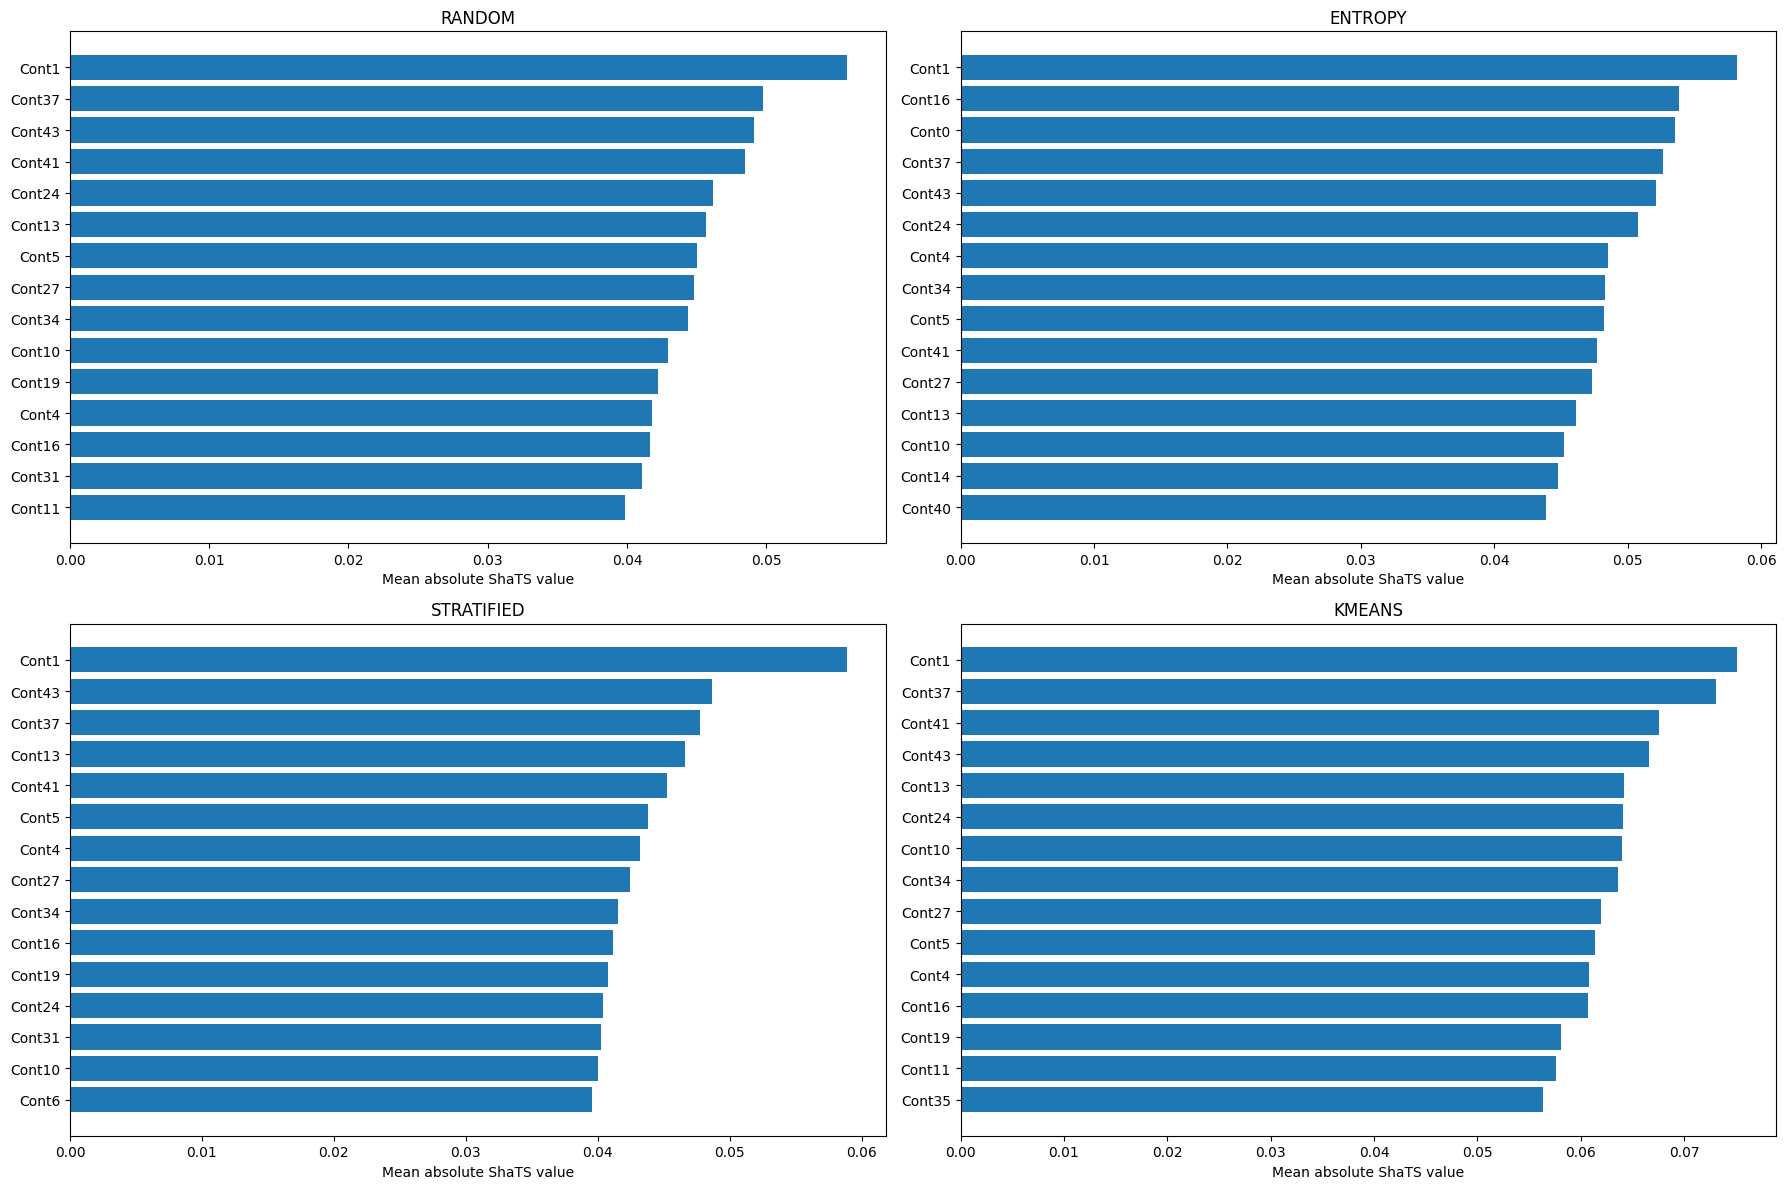

In [46]:
top_k = 15

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax, strategy_name in zip(axes, results.keys()):
    strategy_df = summary_df[summary_df["strategy"] == strategy_name].copy()
    strategy_df = strategy_df.sort_values("mean_abs_shats", ascending=False).head(top_k)
    strategy_df = strategy_df.iloc[::-1]

    ax.barh(strategy_df["feature"], strategy_df["mean_abs_shats"])
    ax.set_title(strategy_name)
    ax.set_xlabel("Mean absolute ShaTS value")

plt.tight_layout()
plt.show()

### 2.8 Compare explanations for one specific window

The next cells plot the feature-level explanations for the same window using each background strategy.


In [47]:
window_to_plot = 0
print(f"Explained test window index inside the selected slice: {window_to_plot}")

Explained test window index inside the selected slice: 0


#### RANDOM background

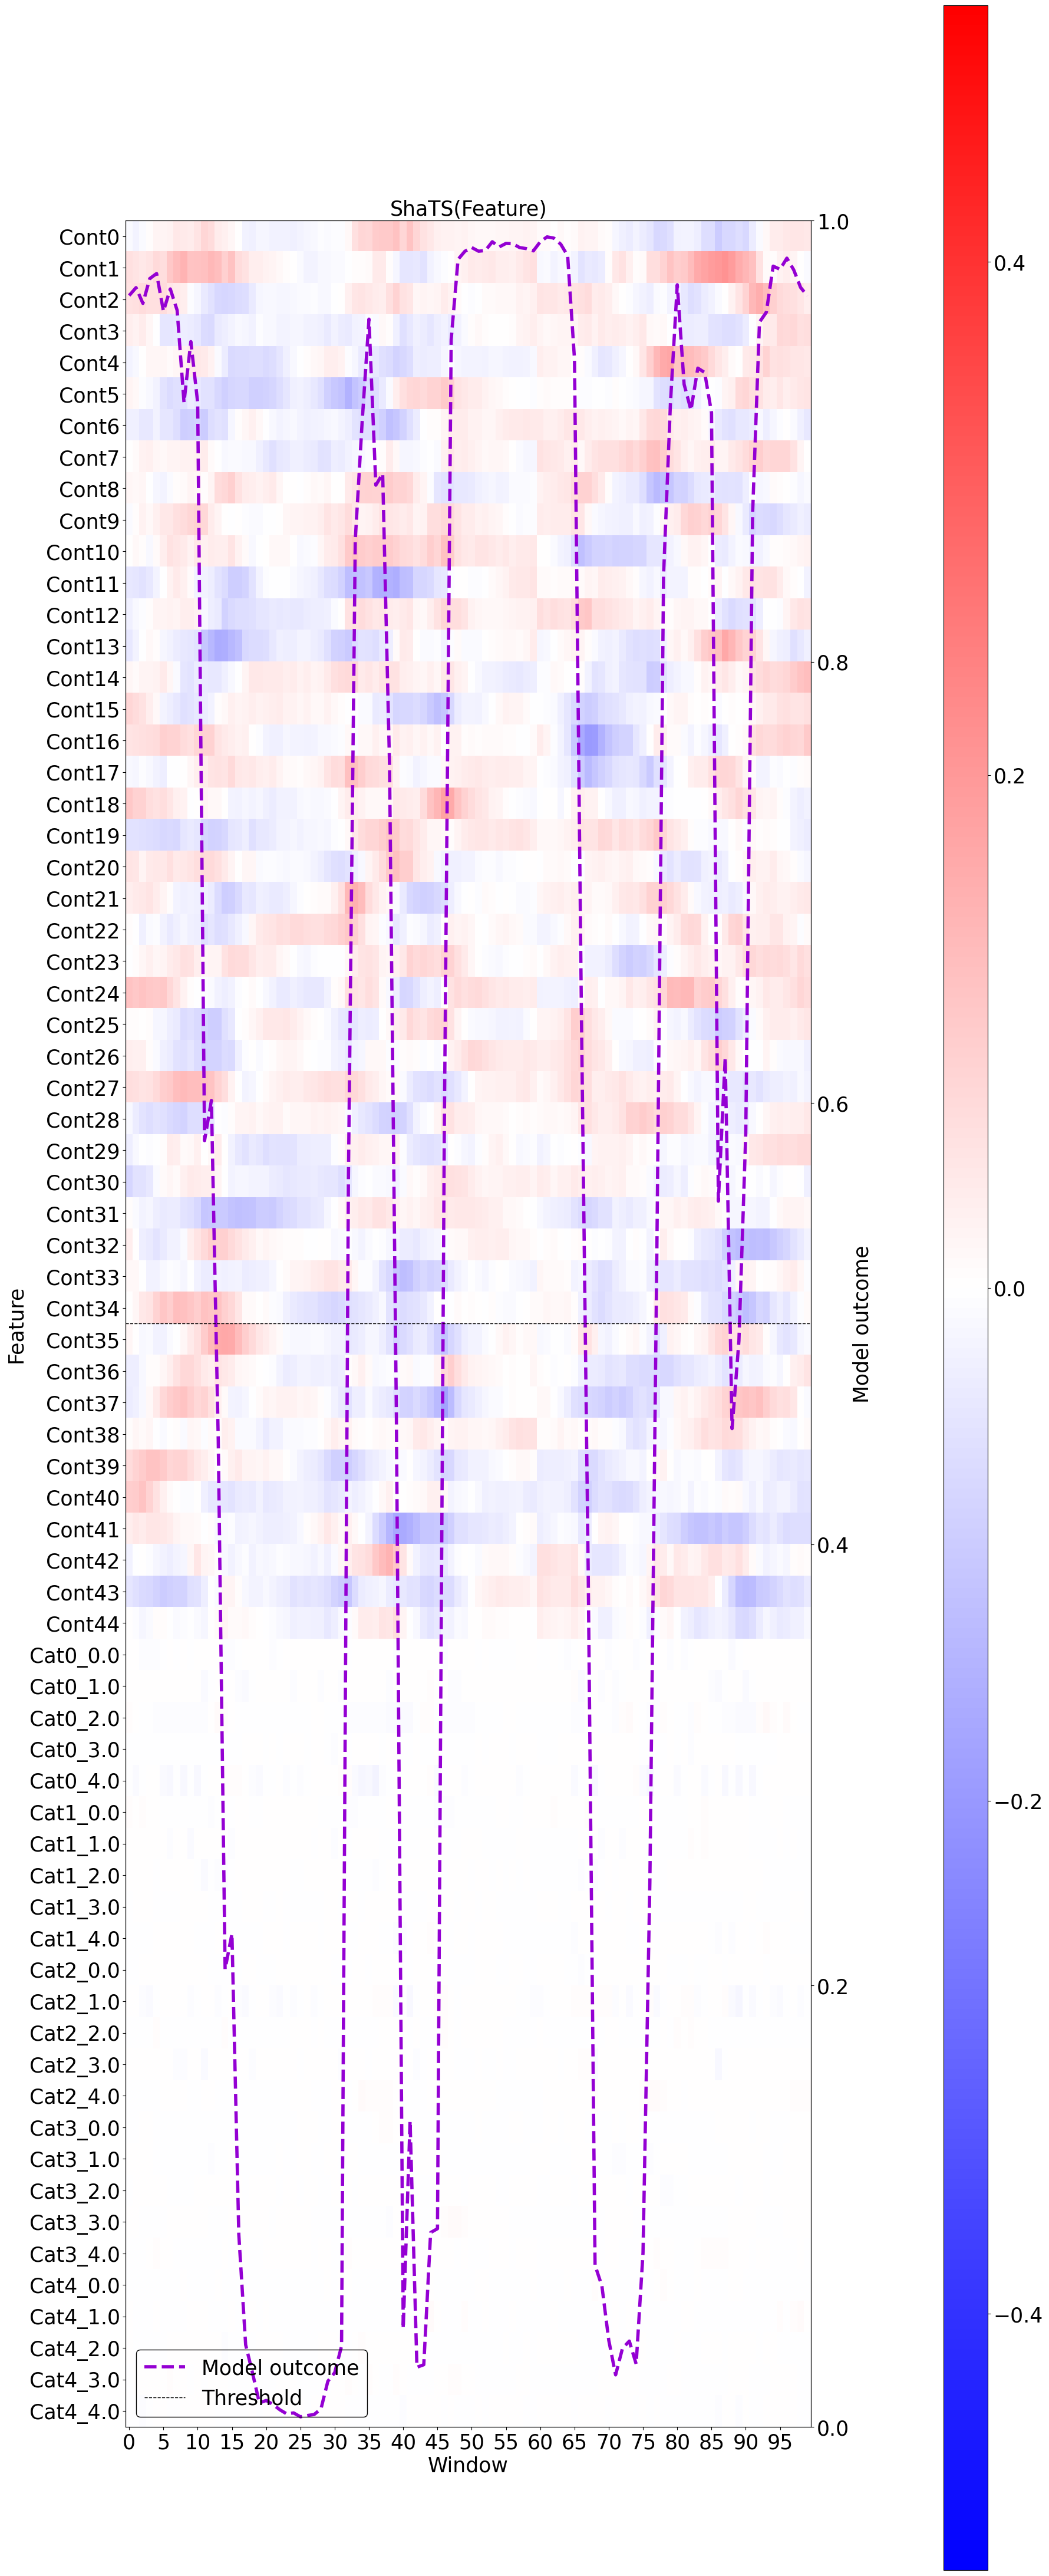

In [48]:
results["RANDOM"]["explainer"].plot(
    results["RANDOM"]["shats_values"][window_to_plot:window_to_plot + 100],
    test_dataset=test_windows[window_to_plot:window_to_plot + 100],
    class_to_explain=1,
)

#### ENTROPY background

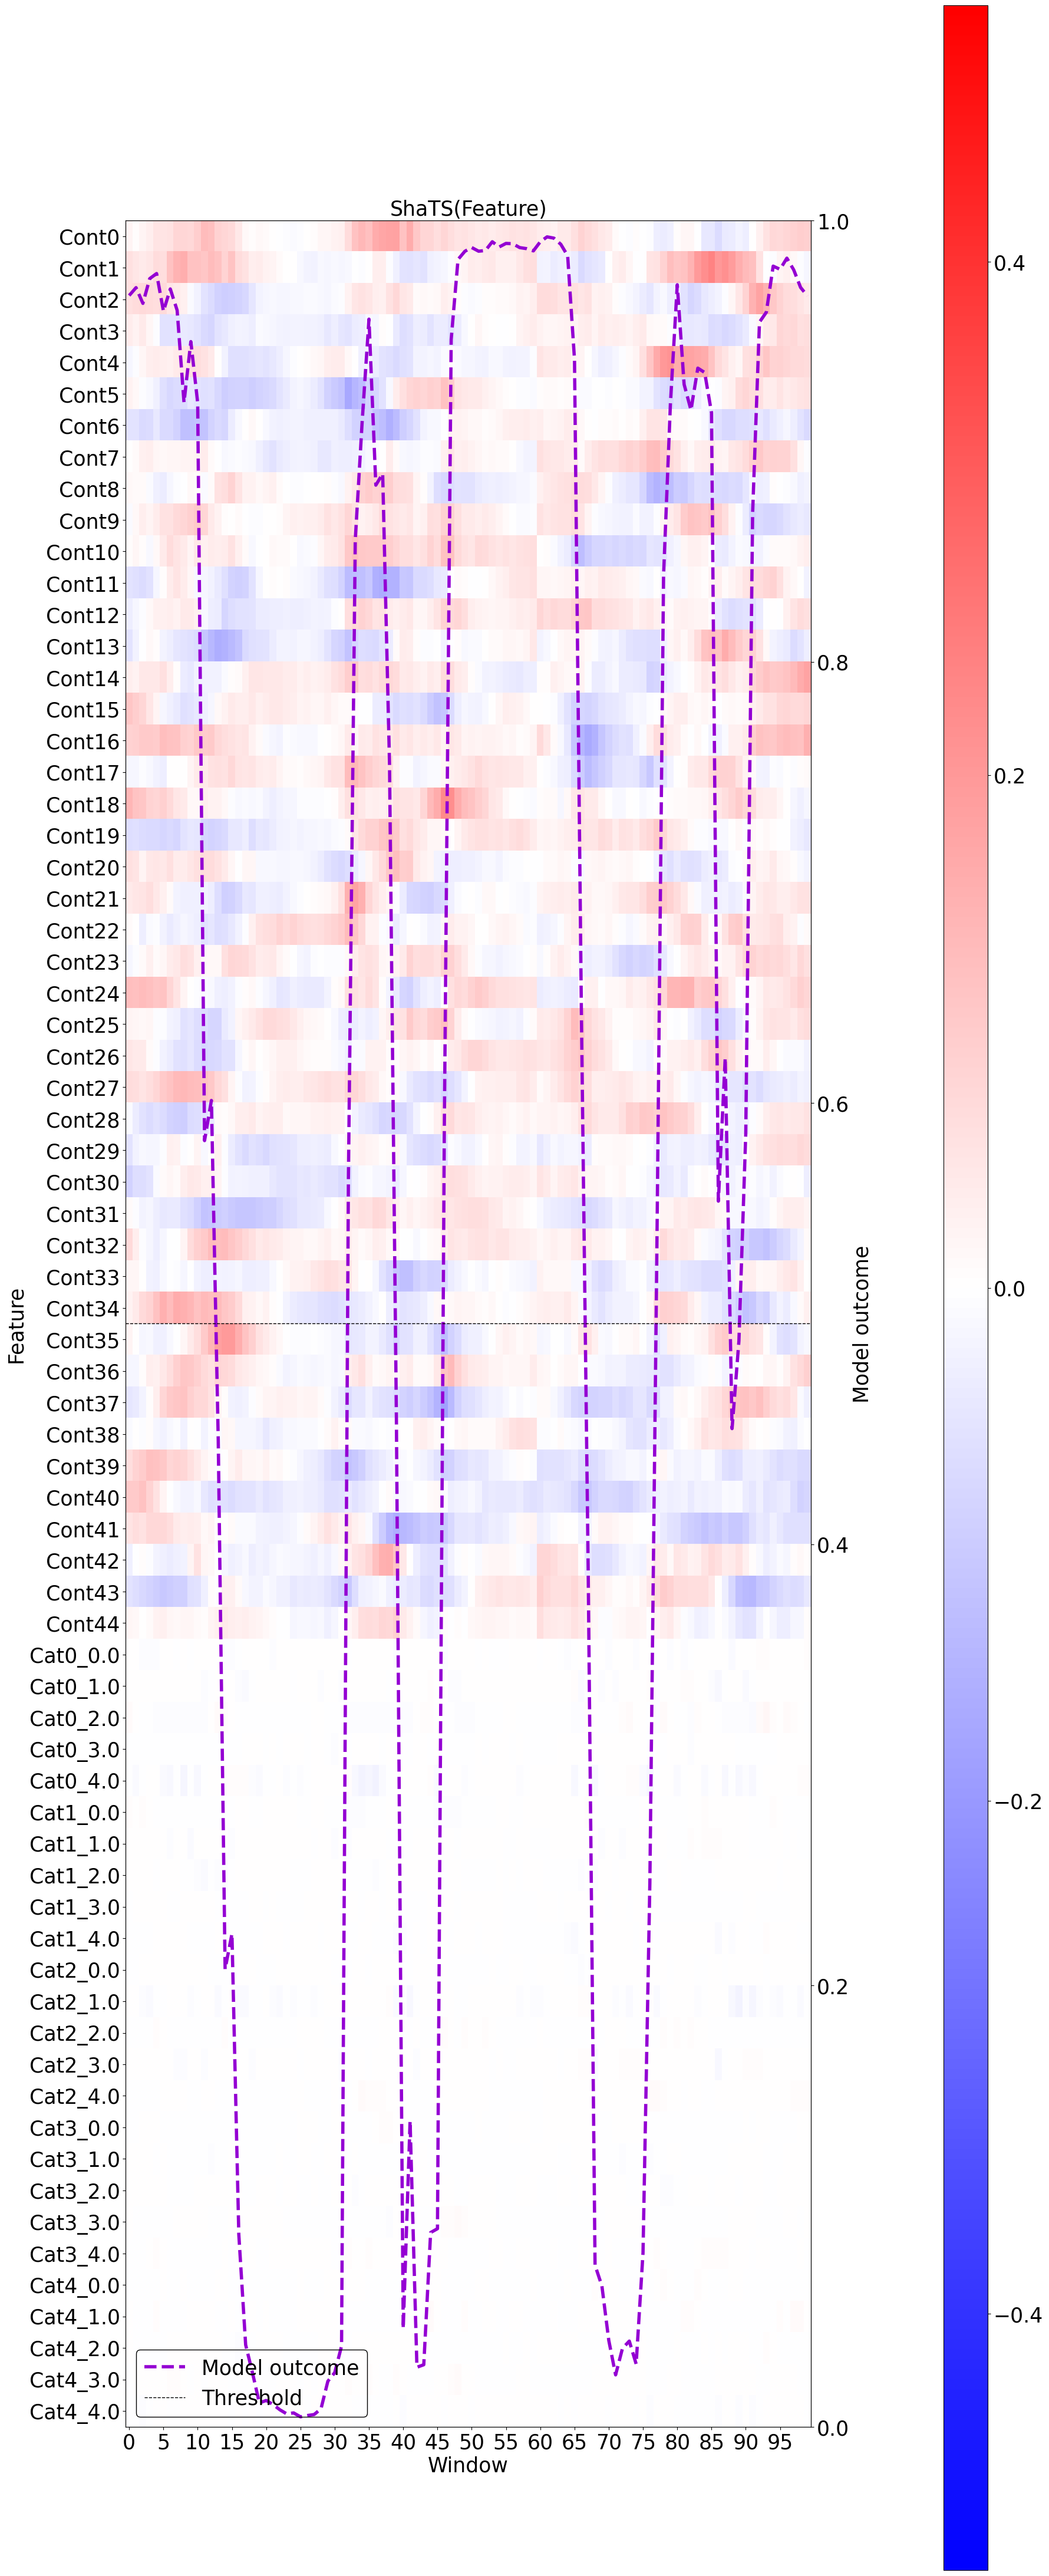

In [49]:
results["ENTROPY"]["explainer"].plot(
    results["ENTROPY"]["shats_values"][window_to_plot:window_to_plot + 100],
    test_dataset=test_windows[window_to_plot:window_to_plot + 100],
    class_to_explain=1,
)

#### STRATIFIED background

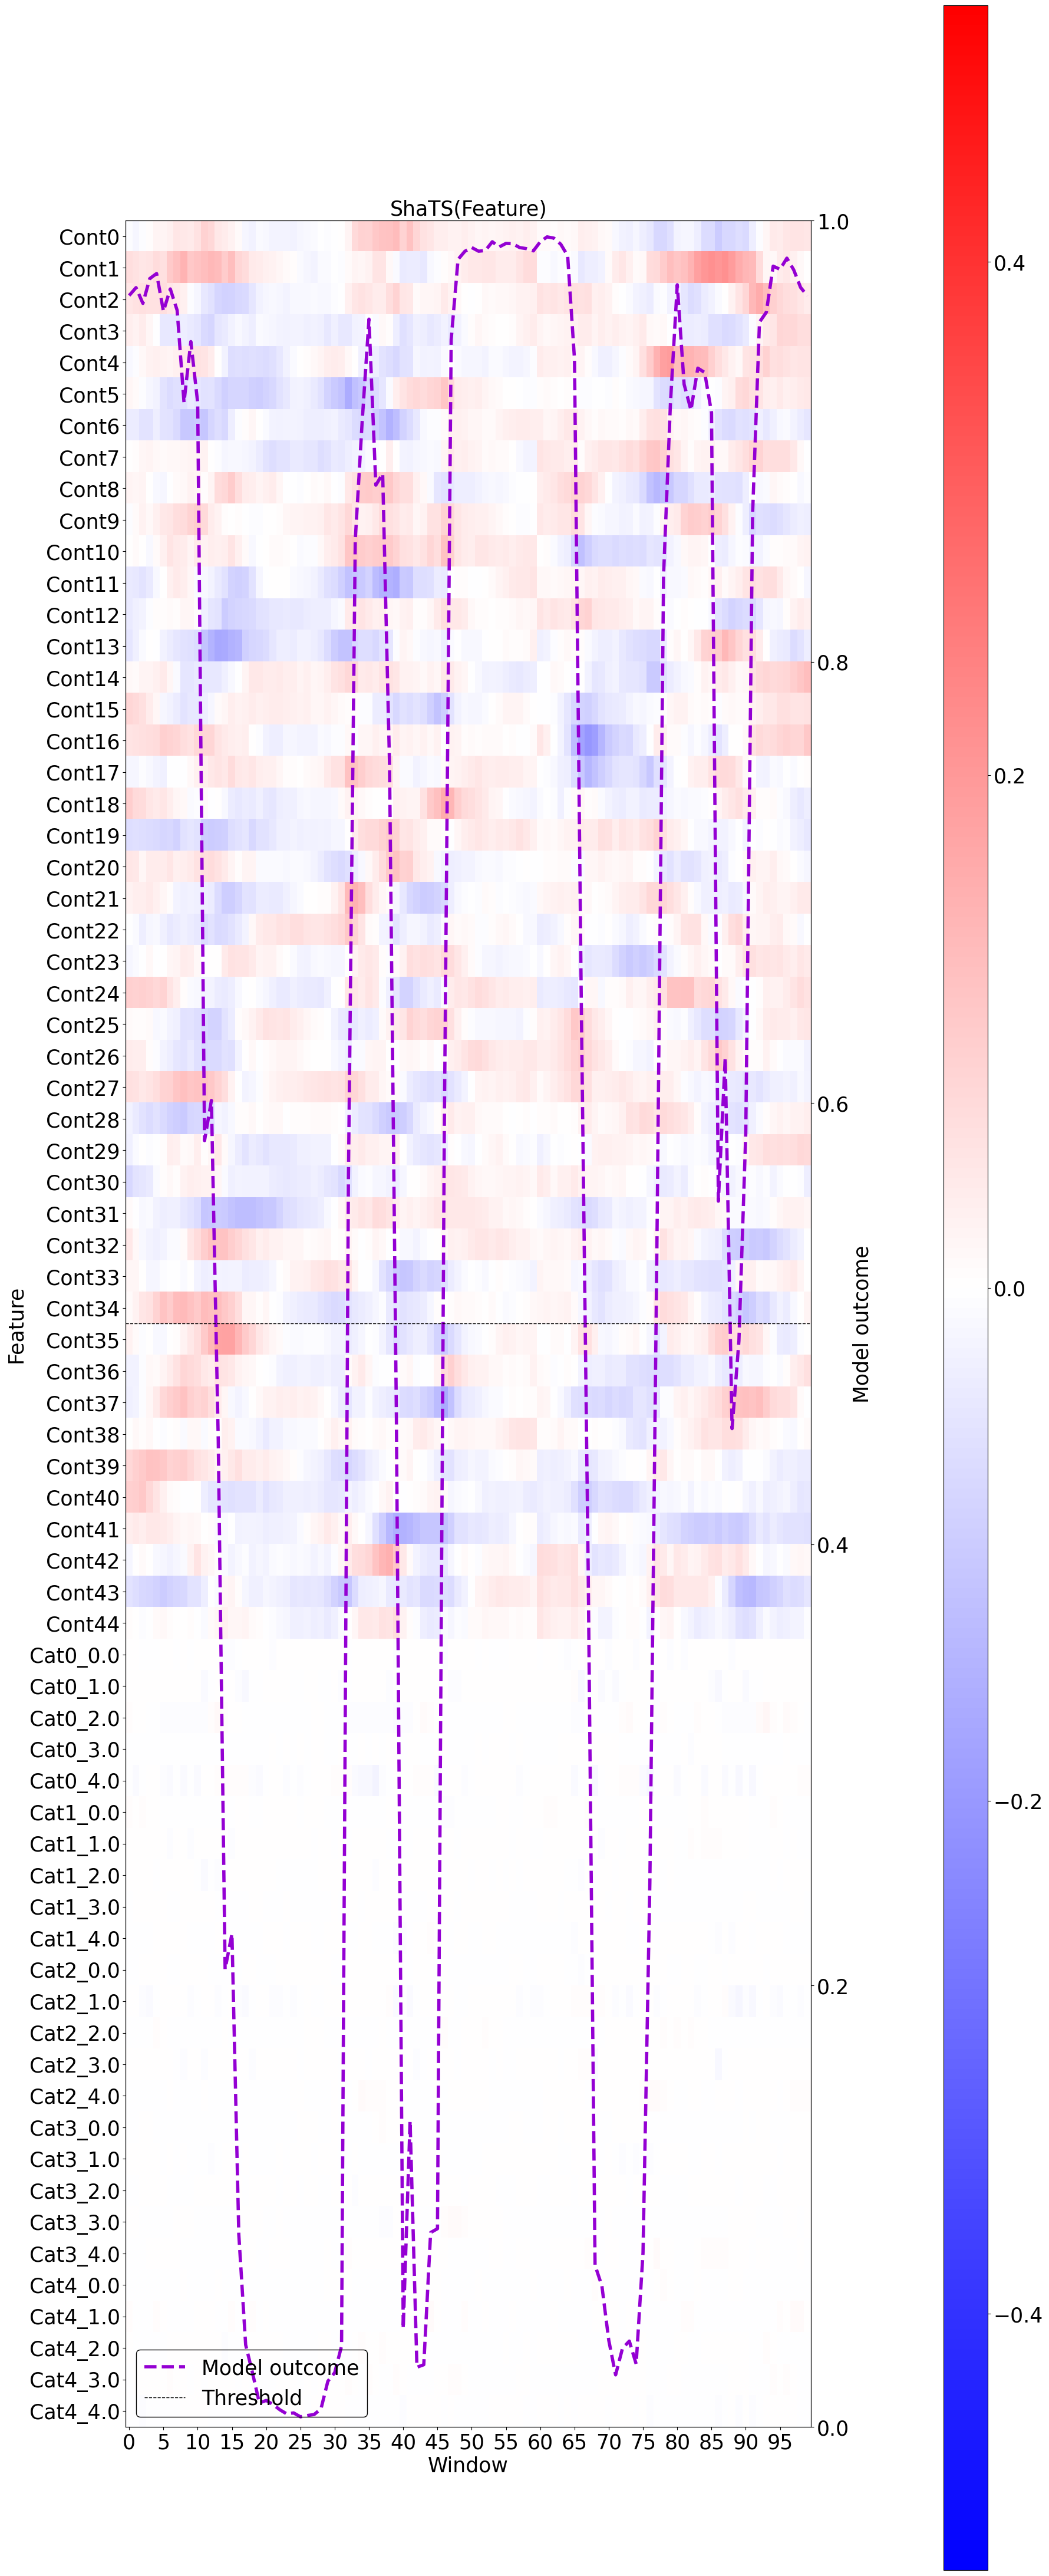

In [50]:
results["STRATIFIED"]["explainer"].plot(
    results["STRATIFIED"]["shats_values"][window_to_plot:window_to_plot + 100],
    test_dataset=test_windows[window_to_plot:window_to_plot + 100],
    class_to_explain=1,
)

#### KMEANS background

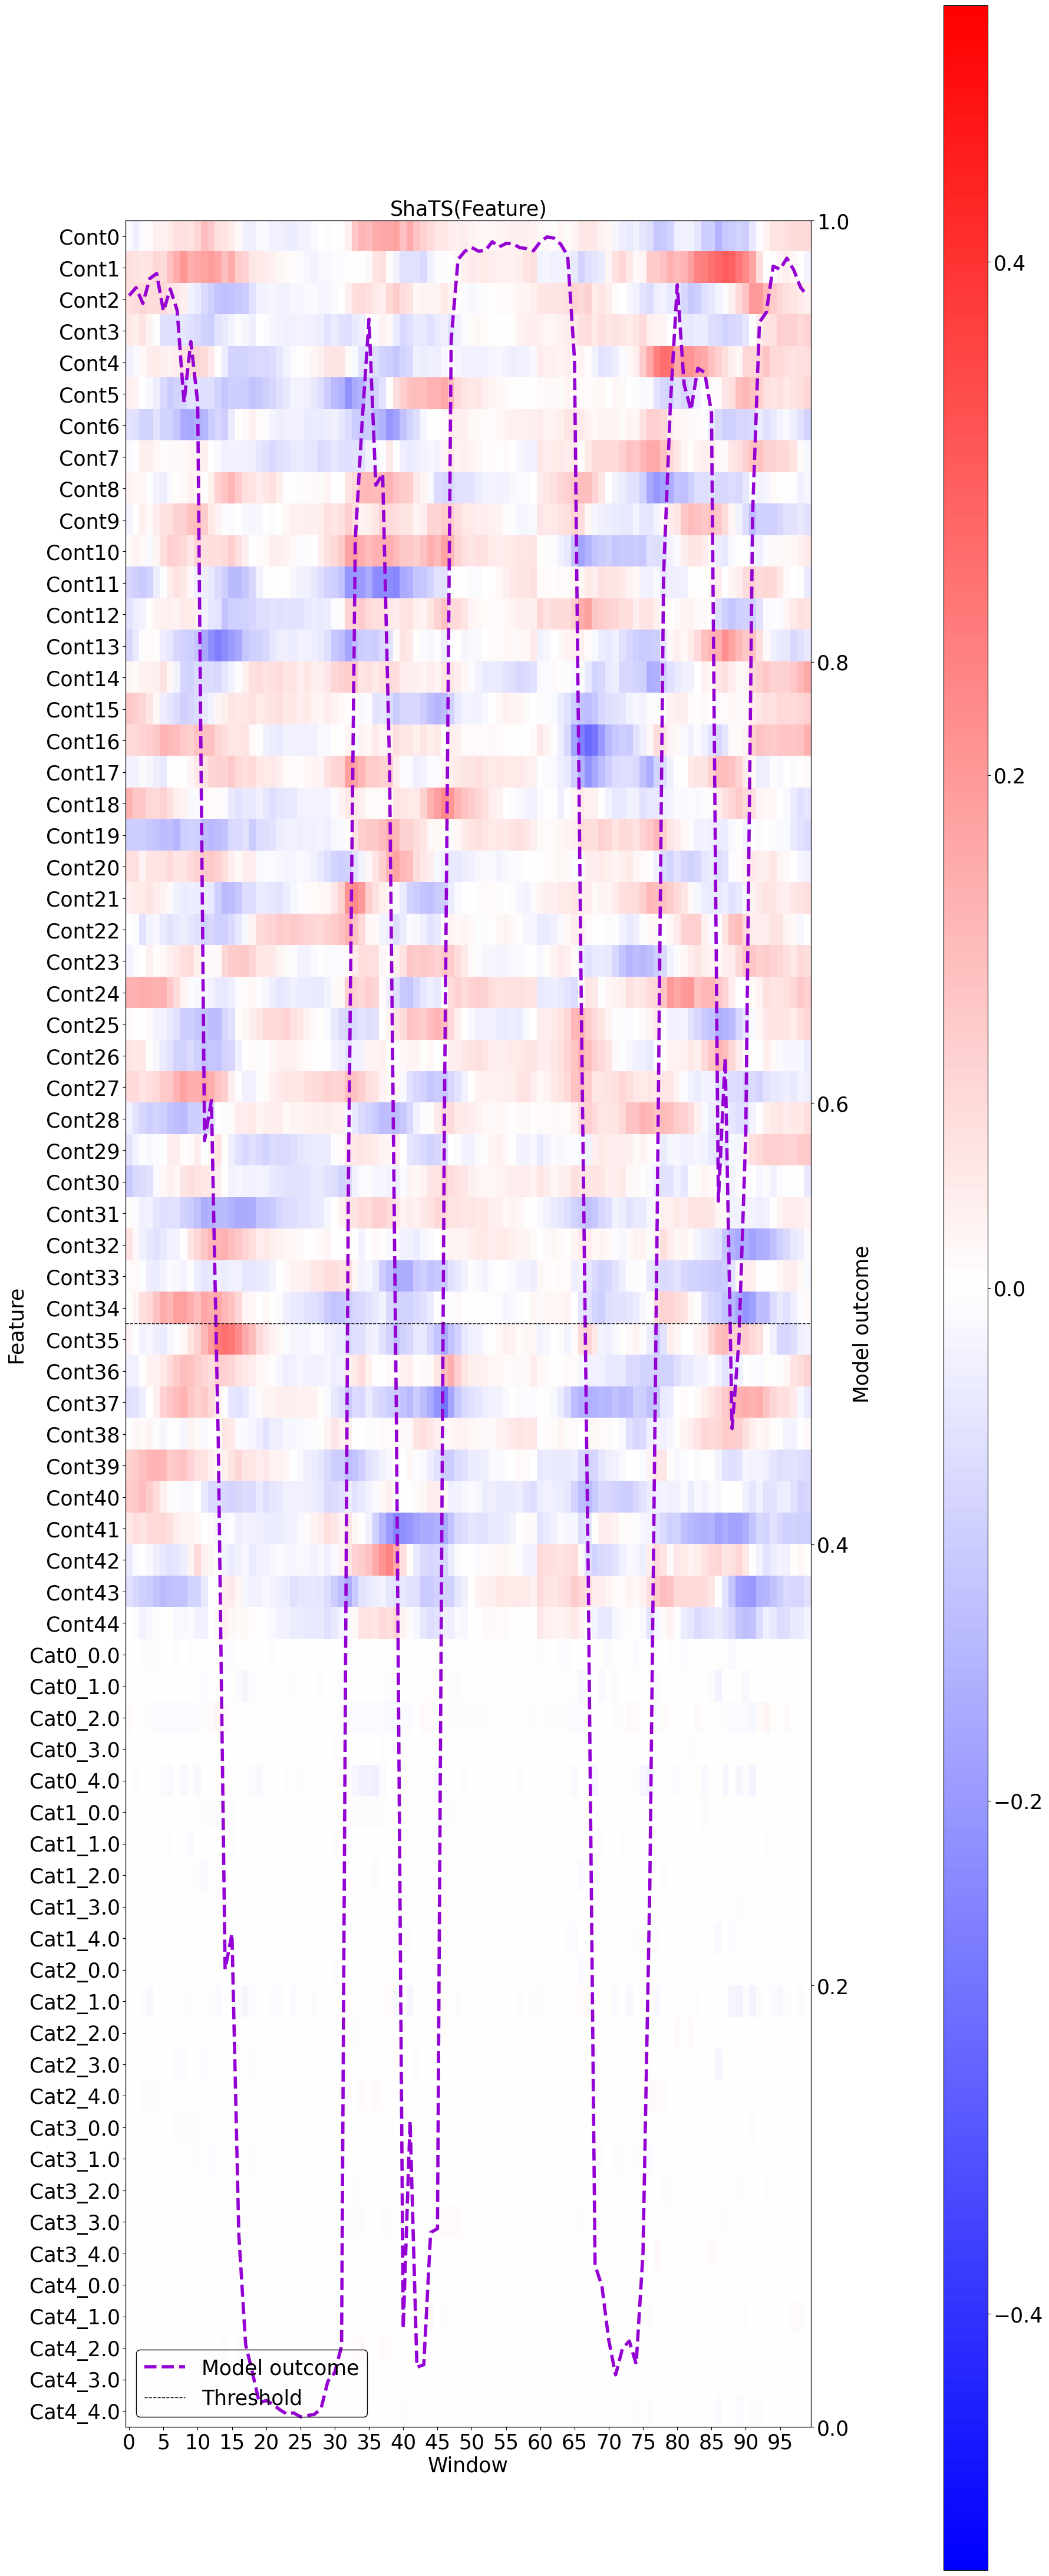

In [51]:
results["KMEANS"]["explainer"].plot(
    results["KMEANS"]["shats_values"][window_to_plot:window_to_plot + 100],
    test_dataset=test_windows[window_to_plot:window_to_plot + 100],
    class_to_explain=1,
)

## 3 - Optional quantitative comparison

This final table compares the feature rankings produced by the different background strategies.


In [52]:
ranking_table = summary_df.copy()
ranking_table["rank"] = ranking_table.groupby("strategy")["mean_abs_shats"].rank(ascending=False, method="dense")
ranking_table = ranking_table.sort_values(["strategy", "rank", "feature"])
ranking_table.head(40)

,feature,mean_abs_shats,strategy,rank
71,Cont1,0.058199,ENTROPY,1.0
86,Cont16,0.053860,ENTROPY,2.0
70,Cont0,0.053515,ENTROPY,3.0
107,Cont37,0.052626,ENTROPY,4.0
113,Cont43,0.052084,ENTROPY,5.0
94,Cont24,0.050779,ENTROPY,6.0
74,Cont4,0.048510,ENTROPY,7.0
104,Cont34,0.048290,ENTROPY,8.0
75,Cont5,0.048176,ENTROPY,9.0
111,Cont41,0.047711,ENTROPY,10.0


### Interpretation notes

- `RANDOM` provides a simple baseline and is usually the fastest background construction strategy.
- `ENTROPY` tends to prioritize more diverse or information-rich windows.
- `STRATIFIED` preserves the class proportions of the training windows and is useful when class balance matters.
- `KMEANS` uses centroids, which can summarize the training distribution with fewer representative windows.

The best strategy depends on the data distribution, the explanation goal, and the trade-off between representativeness and computational cost.
